In [2]:
import random
import matplotlib.pyplot as plt
import pandas as pd
from play_multi_agent import run_game
from IPython.display import clear_output

In [5]:
NUM_GAMES = 300
TRIBES = ["Xin Xi", "Imperius", "Bardur", "Oumaji"]
AGENT_A = "checkpoints/dqn.pt"
AGENT_B = "Random"

results_data = []

print(f"Starting evaluation: {NUM_GAMES} games between DQN and {AGENT_B}")

for i in range(NUM_GAMES):
    # Randomize who plays first
    agents = [AGENT_A, AGENT_B]
    random.shuffle(agents)
    
    # Randomize tribes
    tribes = random.sample(TRIBES, 2)
    
    print(f"\nGame {i+1}/{NUM_GAMES}")
    print(f"Player 0: {agents[0]} ({tribes[0]})")
    print(f"Player 1: {agents[1]} ({tribes[1]})")
    
    # Run the game
    res = run_game(
        agents=agents,
        tribes=tribes,
        level_seed=-1,
        game_seed=-1,
        max_steps=2000,
        visuals=False,
        delay=0.0,
        compile_first=(i == 0)
    )
    
    # Store results
    game_record = {"game_index": i}
    for player in res['players']:
        agent = "DQN" if player['agent'] == AGENT_A else "Random"
        game_record[f"{agent}_tribe"] = player['tribe']
        game_record[f"{agent}_score"] = player['score']
        game_record[f"{agent}_status"] = player['status']
        
    results_data.append(game_record)
    clear_output(wait=True)
    print(f"Finished Game {i+1}/{NUM_GAMES}. Latest Result: DQN {game_record['DQN_status']} ({game_record['DQN_score']}) vs Random {game_record['Random_status']} ({game_record['Random_score']})")

print("\nEvaluation complete!")
df = pd.DataFrame(results_data)
display(df.head())

Finished Game 300/300. Latest Result: DQN LOSS (3497) vs Random WIN (5471)

Evaluation complete!


,game_index,DQN_tribe,DQN_score,DQN_status,Random_tribe,Random_score,Random_status
0,0,Bardur,3399,WIN,Imperius,1750,LOSS
1,1,Bardur,3449,WIN,Xin Xi,3070,LOSS
2,2,Imperius,6930,WIN,Bardur,2323,LOSS
3,3,Bardur,3595,WIN,Oumaji,1997,LOSS
4,4,Imperius,3512,WIN,Xin Xi,1468,LOSS


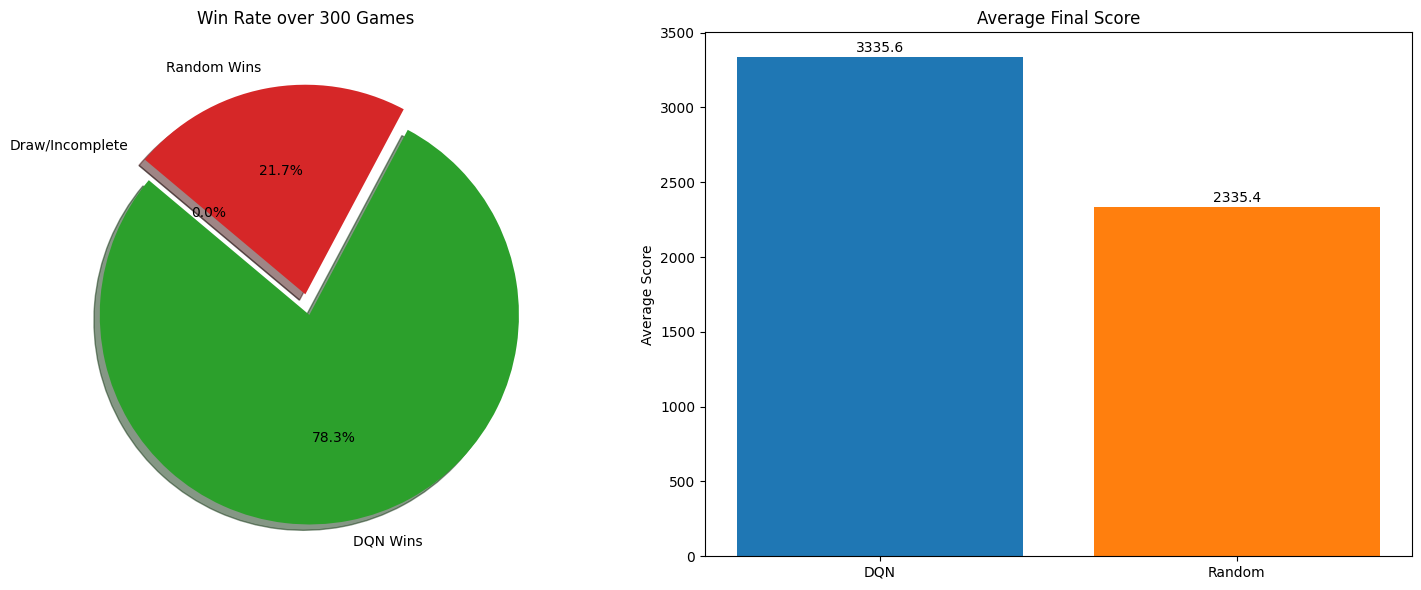

In [7]:
# Plotting the results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 1. Win Rate Pie Chart
dqn_wins = len(df[df['DQN_status'] == 'WIN'])
random_wins = len(df[df['Random_status'] == 'WIN'])
draws = NUM_GAMES - dqn_wins - random_wins

labels = ['DQN Wins', 'Random Wins', 'Draw/Incomplete']
sizes = [dqn_wins, random_wins, draws]
colors = ['#2ca02c', '#d62728', '#7f7f7f']
explode = (0.1, 0, 0)

ax1.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140)
ax1.set_title(f"Win Rate over {NUM_GAMES} Games")

# 2. Average Score Bar Chart
avg_dqn_score = df['DQN_score'].mean()
avg_random_score = df['Random_score'].mean()

agents = ['DQN', 'Random']
scores = [avg_dqn_score, avg_random_score]

ax2.bar(agents, scores, color=['#1f77b4', '#ff7f0e'])
ax2.set_ylabel('Average Score')
ax2.set_title('Average Final Score')

for i, v in enumerate(scores):
    ax2.text(i, v + max(scores)*0.01, str(round(v, 1)), ha='center')

plt.tight_layout()
plt.show()